In [2]:
import os
import tempfile

import anndata
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scvi
import seaborn as sns
import torch

/home/juseppe/miniconda3/envs/flwr-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
scvi.settings.seed = 0
print("Last run with scvi-tools version:", scvi.__version__)

Seed set to 0


Last run with scvi-tools version: 1.3.2


In [4]:
sc.set_figure_params(figsize=(6, 6), frameon=False)
sns.set_theme()
torch.set_float32_matmul_precision("high")
save_dir = tempfile.TemporaryDirectory()

%config InlineBackend.print_figure_kwargs={"facecolor": "w"}
%config InlineBackend.figure_format="retina"

In [5]:
pancreas_adata_path = os.path.join(save_dir.name, "pancreas.h5ad")

pancreas_adata = sc.read(
    pancreas_adata_path,
    backup_url="https://figshare.com/ndownloader/files/24539828",
)
pancreas_adata

100%|██████████| 301M/301M [02:02<00:00, 2.58MB/s]   


AnnData object with n_obs × n_vars = 16382 × 19093
    obs: 'tech', 'celltype', 'size_factors'
    layers: 'counts'

In [6]:
pancreas_adata.obs["tech"].value_counts()

tech
inDrop3       3605
smartseq2     2394
celseq2       2285
inDrop1       1937
inDrop2       1724
smarter       1492
inDrop4       1303
celseq        1004
fluidigmc1     638
Name: count, dtype: int64

In [7]:
query_mask = np.array([s in ["smartseq2", "celseq2"] for s in pancreas_adata.obs["tech"]])

pancreas_ref = pancreas_adata[~query_mask].copy()
pancreas_query = pancreas_adata[query_mask].copy()

In [8]:
sc.pp.highly_variable_genes(pancreas_ref, n_top_genes=2000, batch_key="tech", subset=True)

pancreas_query = pancreas_query[:, pancreas_ref.var_names].copy()

## train


In [9]:
scvi.model.SCVI.setup_anndata(pancreas_ref, batch_key="tech", layer="counts")

/home/juseppe/miniconda3/envs/flwr-env/lib/python3.11/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.layers[counts] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


In [ ]:
scvi_ref = scvi.model.SCVI(
    pancreas_ref,
    use_layer_norm="both",
    use_batch_norm="none",
    encode_covariates=True,
    dropout_rate=0.2,
    n_layers=2,
)
scvi_ref.train()

In [11]:
SCVI_LATENT_KEY = "X_scVI"

pancreas_ref.obsm[SCVI_LATENT_KEY] = scvi_ref.get_latent_representation()
sc.pp.neighbors(pancreas_ref, use_rep=SCVI_LATENT_KEY)
sc.tl.leiden(pancreas_ref)
sc.tl.umap(pancreas_ref)

/tmp/ipykernel_36000/205088744.py:5: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(pancreas_ref)


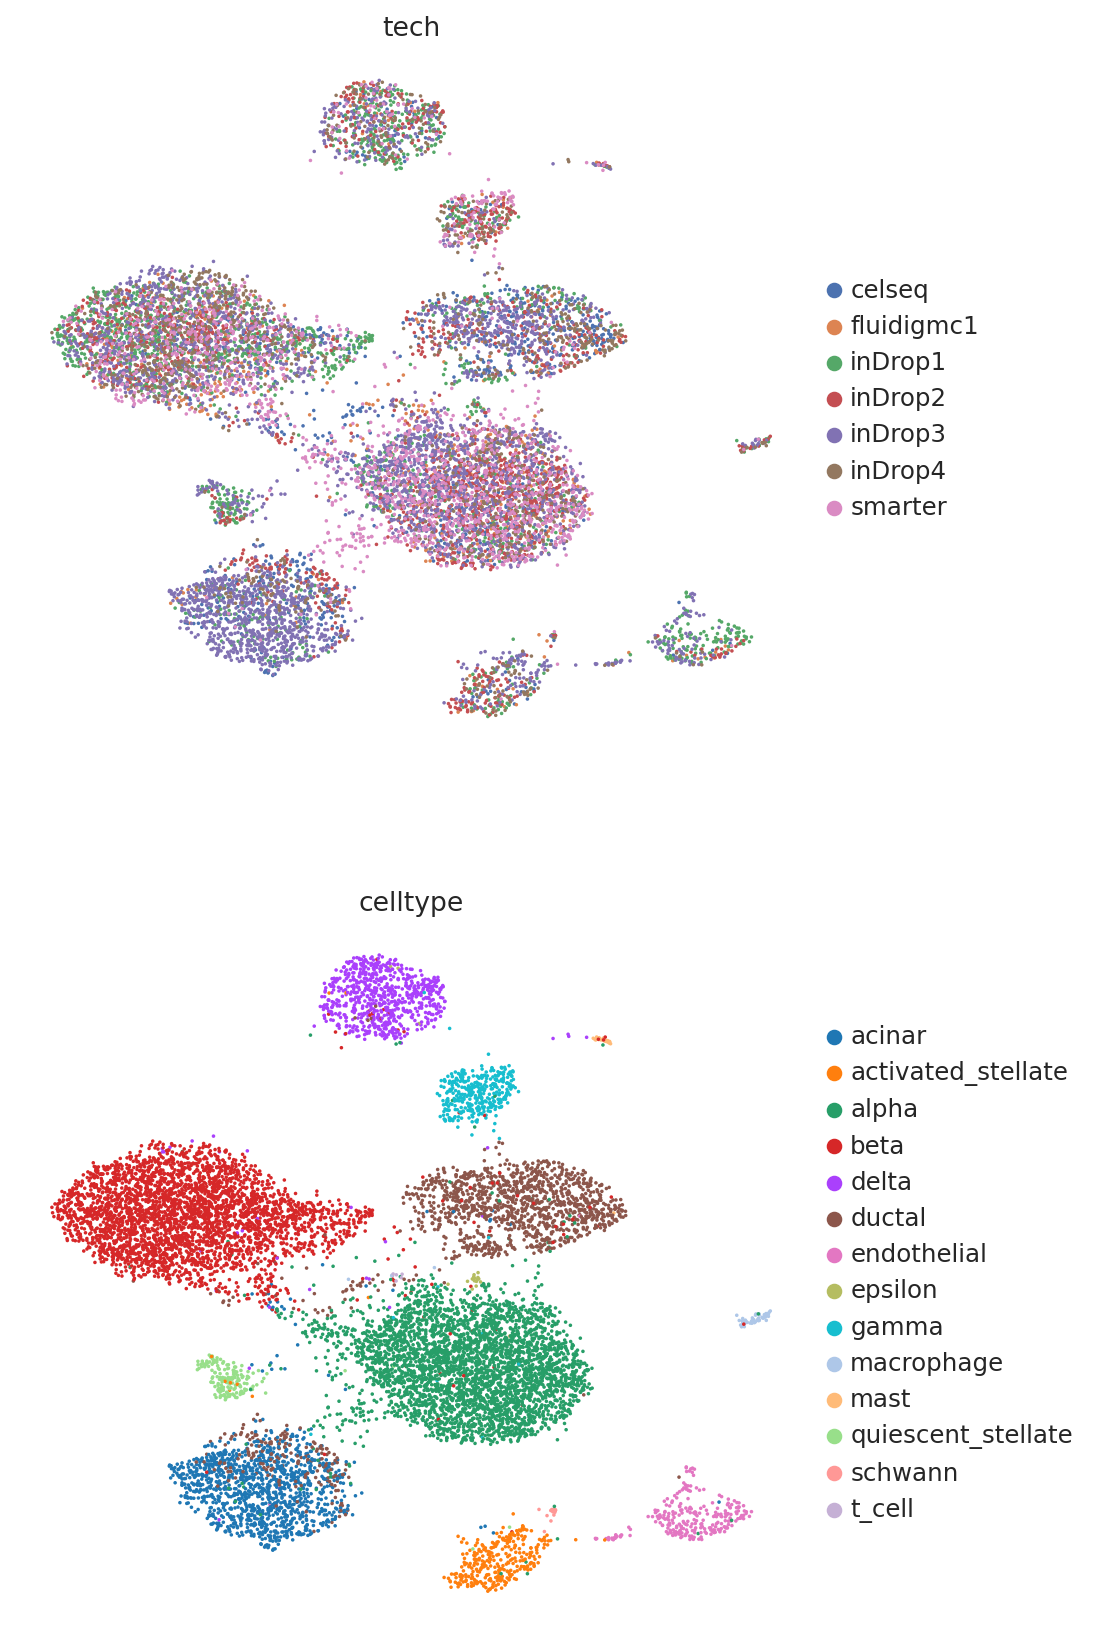

In [12]:
sc.pl.umap(
    pancreas_ref,
    color=["tech", "celltype"],
    frameon=False,
    ncols=1,
)

--

In [13]:
scvi_ref_path = os.path.join(save_dir.name, "pancreas_scvi_ref")
scvi_ref.save(scvi_ref_path, overwrite=True)

In [14]:
# both are valid
scvi.model.SCVI.prepare_query_anndata(pancreas_query, scvi_ref_path)
scvi.model.SCVI.prepare_query_anndata(pancreas_query, scvi_ref)

INFO     File /tmp/tmpt5yf51au/pancreas_scvi_ref/model.pt already downloaded                                       
INFO     Found 100.0% reference vars in query data.                                                                
INFO     Found 100.0% reference vars in query data.                                                                


In [15]:
# both are valid
scvi_query = scvi.model.SCVI.load_query_data(
    pancreas_query,
    scvi_ref_path,
)
scvi_query = scvi.model.SCVI.load_query_data(
    pancreas_query,
    scvi_ref,
)

INFO     File /tmp/tmpt5yf51au/pancreas_scvi_ref/model.pt already downloaded                                       


/home/juseppe/miniconda3/envs/flwr-env/lib/python3.11/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.layers[counts] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)
/home/juseppe/miniconda3/envs/flwr-env/lib/python3.11/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.layers[counts] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


In [ ]:
scvi_query.train(max_epochs=200, plan_kwargs={"weight_decay": 0.0})
pancreas_query.obsm[SCVI_LATENT_KEY] = scvi_query.get_latent_representation()

In [17]:
sc.pp.neighbors(pancreas_query, use_rep=SCVI_LATENT_KEY)
sc.tl.leiden(pancreas_query)
sc.tl.umap(pancreas_query)

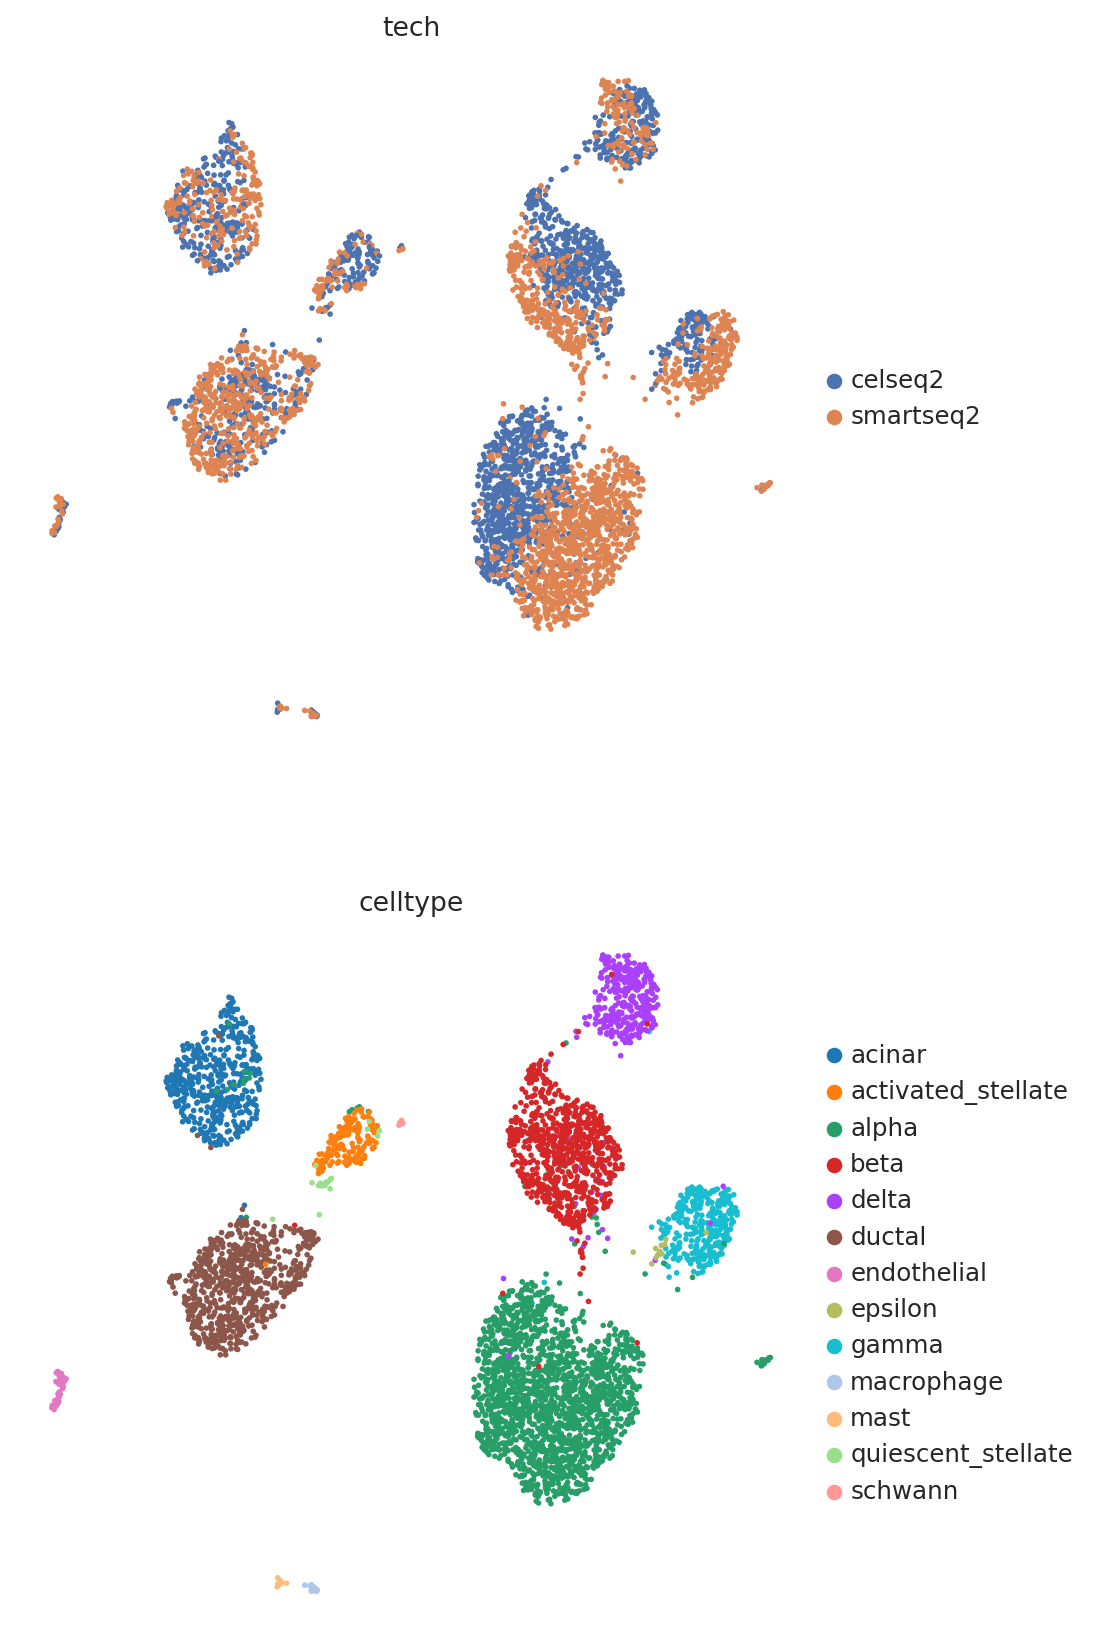

In [18]:
sc.pl.umap(
    pancreas_query,
    color=["tech", "celltype"],
    frameon=False,
    ncols=1,
)

In [19]:
pancreas_full = anndata.concat([pancreas_query, pancreas_ref])
pancreas_full

AnnData object with n_obs × n_vars = 16382 × 2000
    obs: 'tech', 'celltype', 'size_factors', '_scvi_batch', '_scvi_labels', 'leiden'
    obsm: 'X_scVI', 'X_umap'
    layers: 'counts'

In [20]:
pancreas_full.obsm[SCVI_LATENT_KEY] = scvi_query.get_latent_representation(pancreas_full)

INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


/home/juseppe/miniconda3/envs/flwr-env/lib/python3.11/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.layers[counts] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


In [21]:
sc.pp.neighbors(pancreas_full, use_rep=SCVI_LATENT_KEY)
sc.tl.leiden(pancreas_full)
sc.tl.umap(pancreas_full)

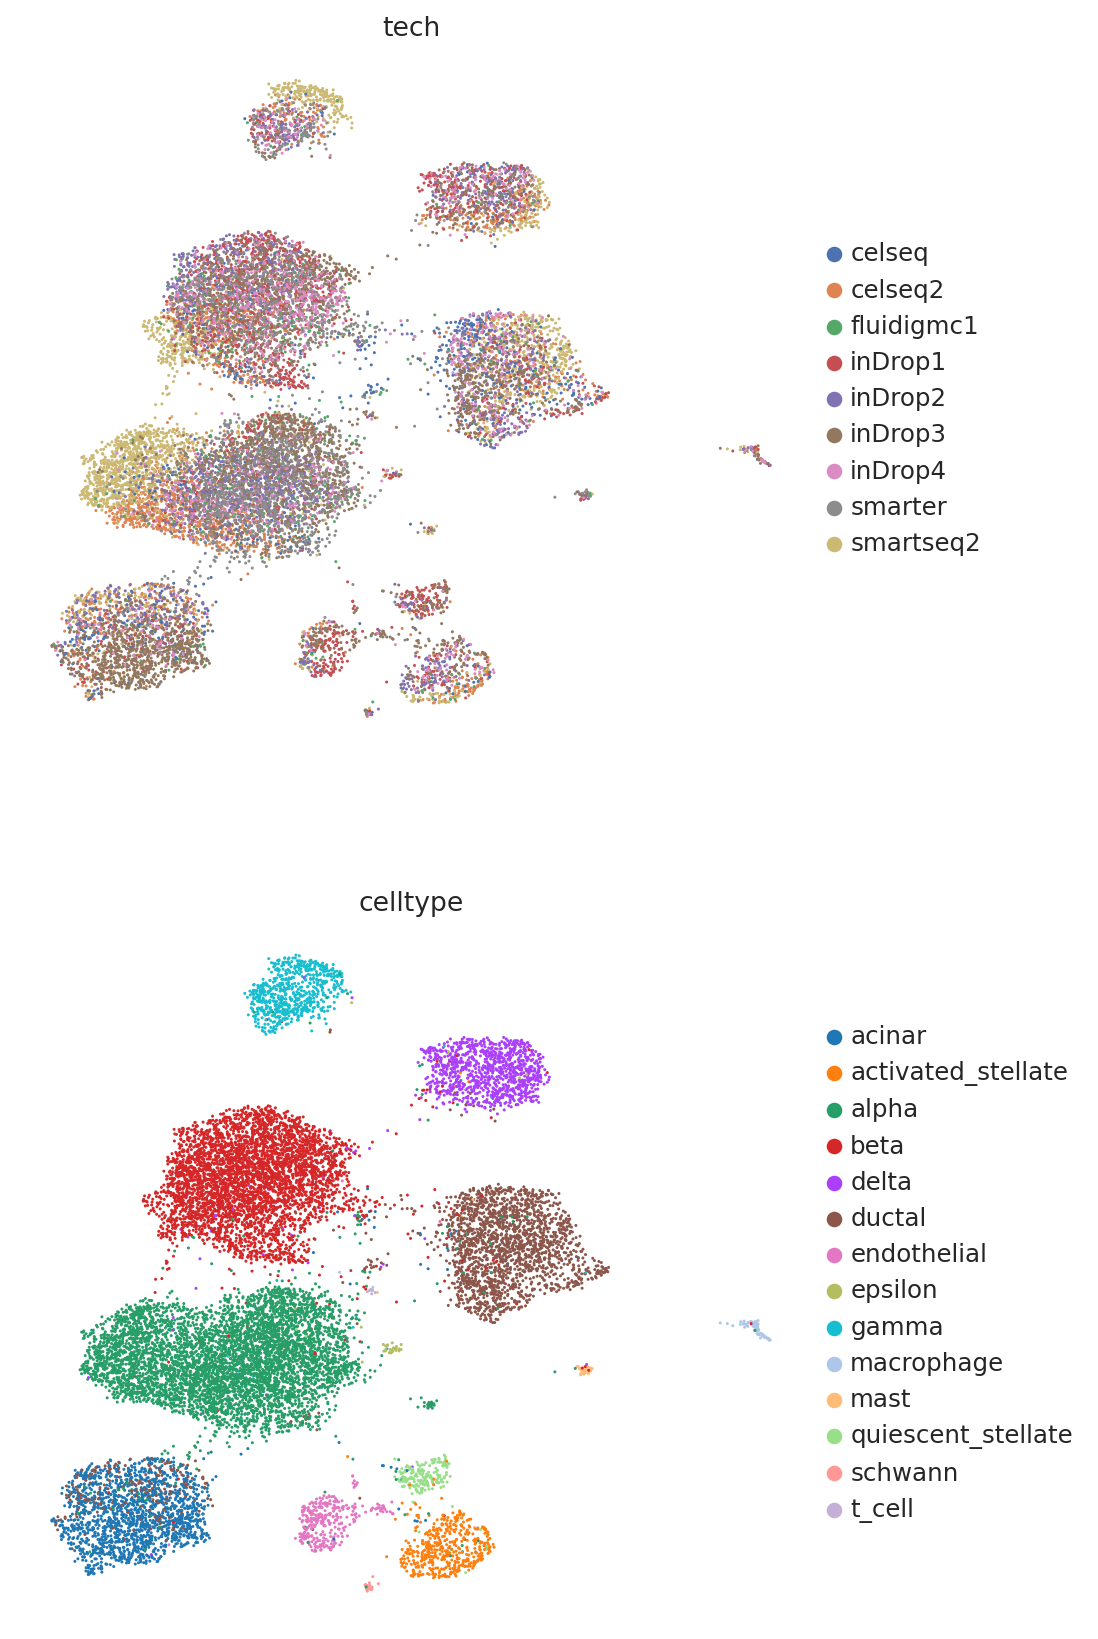

In [22]:
sc.pl.umap(
    pancreas_full,
    color=["tech", "celltype"],
    frameon=False,
    ncols=1,
)